# Rule-Based ISAC Vehicle Mode Selection

Tests the no-learning baseline for the vehicle mode-selection problem (Section III-B):
a vehicle **senses** its current zone iff that zone's Age of Zone Information (AoZI)
has reached a fixed `threshold`, and **communicates** otherwise.

```
a_k(t) = 1{ AoZI_{z_k(t)}(t) >= threshold }
```

Implemented as `MetaLoreEnv.select_vehicle_modes_rule_based()`. No training, no
parameters beyond `threshold`. This is the reference the multi-agent RL mode-selection
policy will later be compared against; the macro resource split (`bw_split`, `comp_split`)
is held fixed here since we're isolating the mode-selection decision only.

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv
from metalore.config import isac_vehicle_config

print('MetaLore-ISAC imported successfully!')

MetaLore-ISAC imported successfully!


## 1. Create & Reset Environment

In [2]:
env = SingleCellEnv(config=isac_vehicle_config())
obs, info = env.reset()

print(f'Base Stations : {env.num_bs}')
print(f'ISAC vehicles : {env.num_isac_vehicles}')
print(f'Sensors       : {env.num_sensors}')
print(f'Zones         : {env.num_zones_x} x {env.num_zones_y} = {env.num_zones_x * env.num_zones_y}')
print(f'Area          : {env.width} x {env.height} m')
print(f'Max Steps     : {env.EP_MAX_TIME}')

Base Stations : 1
ISAC vehicles : 10
Sensors       : 10
Zones         : 10 x 10 = 100
Area          : 200.0 x 200.0 m
Max Steps     : 100


## 2. Sanity Check: Initial Decisions

Note: `AoZI(t) = t - last_sensed`, and `last_sensed = -1` for a never-sensed zone,
so at `t=0` **every** zone (sensed or not) shows `AoZI = 1` — the age formula can't
distinguish "genuinely stale" from "episode just started" this early on. With
`threshold=5`, that means no vehicle senses anything until `t` itself reaches
`threshold - 1`, purely from the clock running, before coverage matters at all.
This is a real property of the rule + age formula, not a notebook bug — worth
keeping in mind when interpreting early-episode behavior below.

In [3]:
THRESHOLD = 5.0   # AoZI (in slots) a zone must reach before a vehicle will sense it

initial_modes = env.select_vehicle_modes_rule_based(threshold=THRESHOLD)
for v, sense in zip(env.active_isac_vehicles, initial_modes):
    zone = env.zone_map.get_zone(v.x, v.y)
    age = env.zone_map.aozi(env.time)[zone]
    print(f'vehicle {v.id}: zone={zone}  AoZI={age}  -> {"SENSE" if sense else "COMM"}')

print(f'\nt={env.time}, threshold={THRESHOLD} -> all vehicles communicate until t reaches threshold-1,')
print('since AoZI=t+1 everywhere on an unsensed map. Expected, not a bug.')

vehicle 0: zone=(9, 1)  AoZI=1  -> COMM
vehicle 1: zone=(3, 2)  AoZI=1  -> COMM
vehicle 2: zone=(0, 1)  AoZI=1  -> COMM
vehicle 3: zone=(3, 3)  AoZI=1  -> COMM
vehicle 4: zone=(6, 4)  AoZI=1  -> COMM
vehicle 5: zone=(6, 2)  AoZI=1  -> COMM
vehicle 6: zone=(1, 3)  AoZI=1  -> COMM
vehicle 7: zone=(0, 3)  AoZI=1  -> COMM
vehicle 8: zone=(4, 7)  AoZI=1  -> COMM
vehicle 9: zone=(8, 0)  AoZI=1  -> COMM

t=0, threshold=5.0 -> all vehicles communicate until t reaches threshold-1,
since AoZI=t+1 everywhere on an unsensed map. Expected, not a bug.


## 3. Run a Full Episode

Each step: compute modes from the rule, build the action
`[bw_split, comp_split, mode_v0, ..., mode_vN]` (macro split fixed at 0.5/0.5),
step the environment, and log what happened.

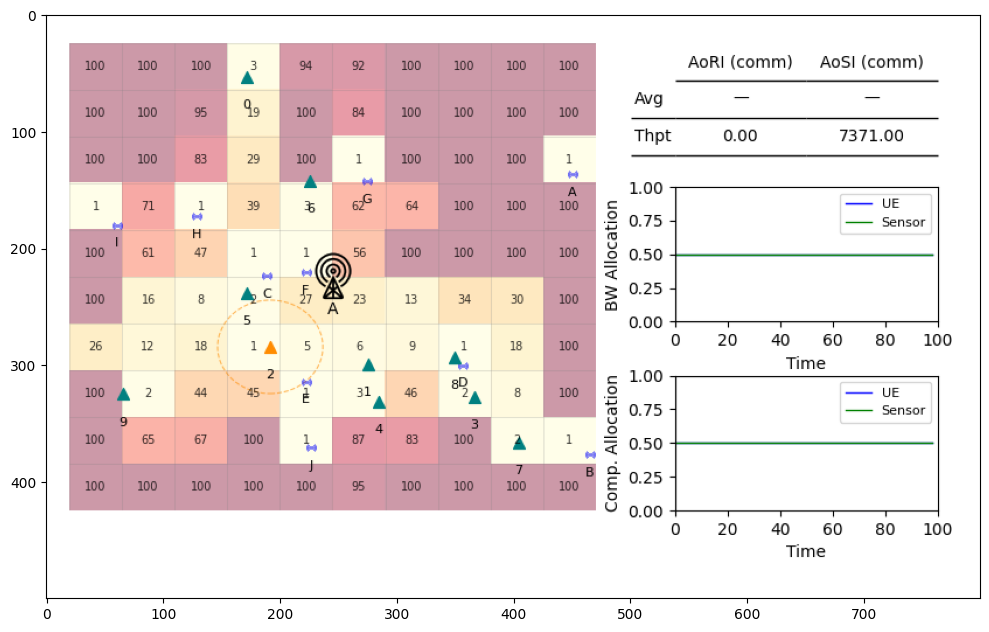

Episode ended at step 100

Steps completed : 100
Total reward    : 0.0000


In [4]:
N_STEPS = env.EP_MAX_TIME
obs, info = env.reset()

rewards = []
mode_history = []   # list of (n_sensing, n_comm) per step


for step in range(N_STEPS):
    modes = env.select_vehicle_modes_rule_based(threshold=THRESHOLD)
    mode_actions = [1.0 if m else 0.0 for m in modes]
    action = [0.5, 0.5] + mode_actions

    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    mode_history.append((sum(modes), len(modes) - sum(modes)))

    if terminated or truncated:
        print(f'Episode ended at step {step+1}')
        break
    
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

print()
print(f'Steps completed : {len(rewards)}')
print(f'Total reward    : {sum(rewards):.4f}')

## 4. Final State Snapshot

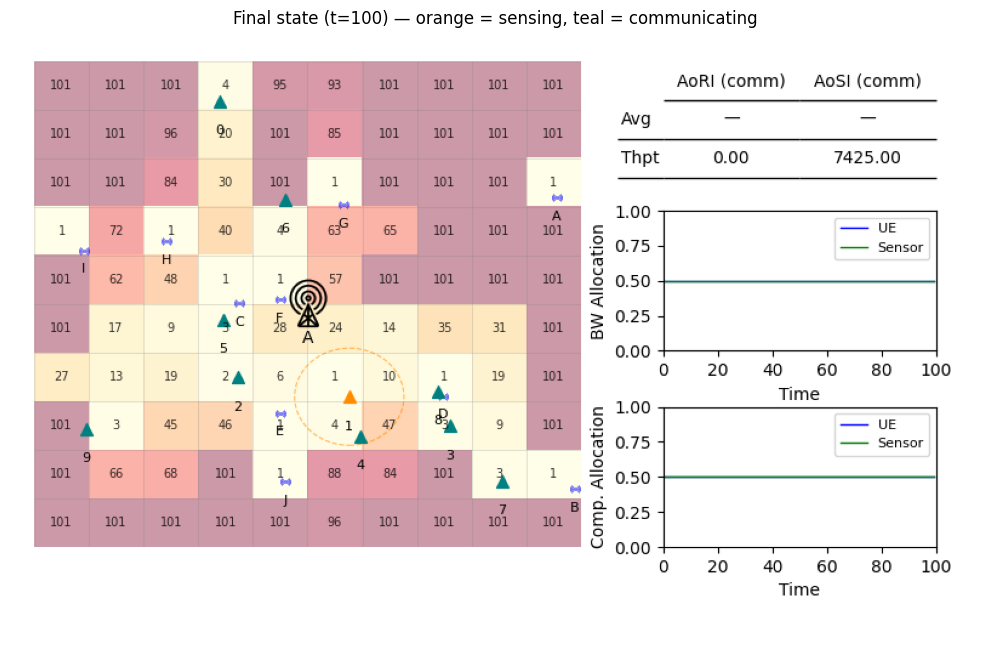

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(env.render())
ax.axis('off')
ax.set_title(f'Final state (t={env.time}) — orange = sensing, teal = communicating')
plt.tight_layout()
plt.show()

## 5. Episode Metrics Summary

In [6]:
ep = env.metrics.finalize(env.job_tracker)

print(f"Jobs generated  : {ep['jobs_generated']}")
print(f"Jobs transmitted: {ep['jobs_transmitted']}")
print(f"Jobs processed  : {ep['jobs_processed']}")
print(f"Completion rate : {ep['job_completion_rate']:.1%}")
print(f"Total reward    : {ep['total_reward']:.4f}")
print()
print(f"mean AoRI (ISAC_COMM)    : {ep['mean_aori_isac_comm']}")
print(f"mean AoRI (ISAC_SENSING) : {ep['mean_aori_isac_sensing']}")
print(f"mean AoSI (ISAC_COMM)    : {ep['mean_aosi_isac_comm']}")

Jobs generated  : 2000
Jobs transmitted: 1999
Jobs processed  : 1162
Completion rate : 58.1%
Total reward    : 0.0000

mean AoRI (ISAC_COMM)    : None
mean AoRI (ISAC_SENSING) : 0.0
mean AoSI (ISAC_COMM)    : None


## 6. Zone Freshness Outcome

Zones ever sensed : 55 / 100  (55.0%)
Mean AoZI (sensed) : 31.78
Max AoZI (sensed)  : 96
Never sensed       : 45 zones (shown as 0 age below, NOT actually fresh)


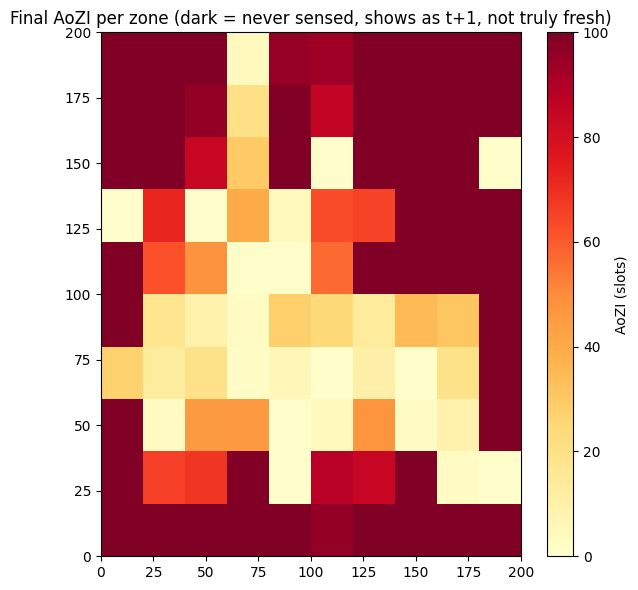

In [7]:
ages = env.zone_map.aozi(env.time)
ever_sensed = env.zone_map.last_sensed >= 0   # NOT ages >= 0 -- that's trivially true
                                                # even for never-sensed zones, since
                                                # aozi(t) = t - (-1) = t+1 >= 0 always.
pct_sensed = 100 * ever_sensed.sum() / ever_sensed.size

print(f'Zones ever sensed : {ever_sensed.sum()} / {ever_sensed.size}  ({pct_sensed:.1f}%)')
print(f'Mean AoZI (sensed) : {ages[ever_sensed].mean():.2f}' if ever_sensed.any() else 'Mean AoZI (sensed) : n/a')
print(f'Max AoZI (sensed)  : {ages[ever_sensed].max()}' if ever_sensed.any() else 'Max AoZI (sensed)  : n/a')
print(f'Never sensed       : {(~ever_sensed).sum()} zones (shown as 0 age below, NOT actually fresh)')

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    ages.T, extent=[0, env.width, 0, env.height], origin='lower',
    cmap='YlOrRd', aspect='auto', vmin=0, vmax=env.EP_MAX_TIME,
)
ax.set_title('Final AoZI per zone (dark = never sensed, shows as t+1, not truly fresh)')
plt.colorbar(im, ax=ax, label='AoZI (slots)')
plt.tight_layout()
plt.show()

## 7. Sense vs. Communicate Behavior Over Time

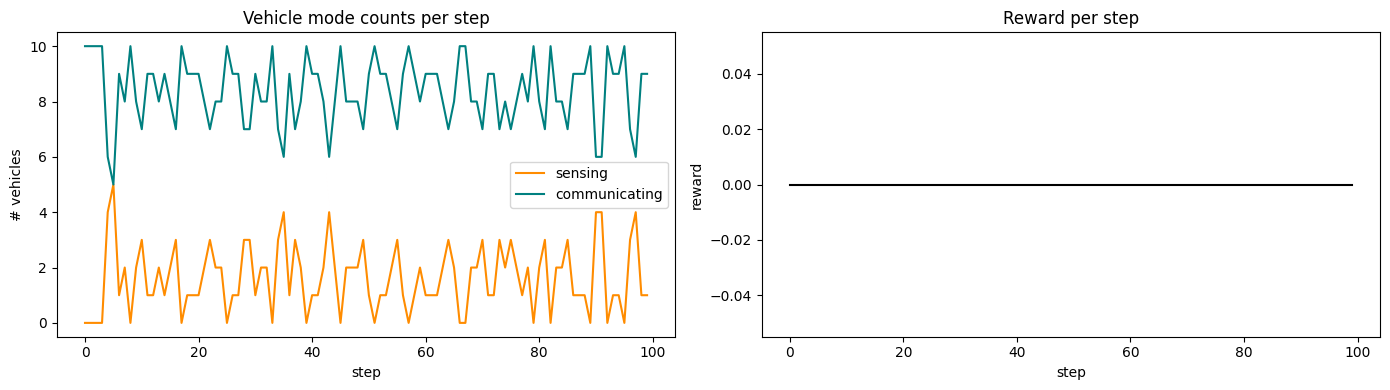

Total vehicle-steps sensing     : 162
Total vehicle-steps communicating: 838
Fraction sensing                : 16.2%


In [8]:
n_sense = [h[0] for h in mode_history]
n_comm = [h[1] for h in mode_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(n_sense, label='sensing', color='darkorange')
axes[0].plot(n_comm, label='communicating', color='teal')
axes[0].set_xlabel('step')
axes[0].set_ylabel('# vehicles')
axes[0].set_title('Vehicle mode counts per step')
axes[0].legend()

axes[1].plot(rewards, color='black')
axes[1].set_xlabel('step')
axes[1].set_ylabel('reward')
axes[1].set_title('Reward per step')

plt.tight_layout()
plt.show()

total_sense = sum(n_sense)
total_comm = sum(n_comm)
print(f'Total vehicle-steps sensing     : {total_sense}')
print(f'Total vehicle-steps communicating: {total_comm}')
print(f'Fraction sensing                : {total_sense / (total_sense + total_comm):.1%}')